# **PUC-Rio | Departamento de Engenharia Industrial**
# **ENG 4560: Projeto Integrado VI - Distribuição Física**

---

# **Aula 7 — Heurísticas construtivas - Nearest Neighbor**  
**Prof. Marcello Congro (marcellocongro@puc-rio.br)**

---

### **Objetivo desta aula prática**

Na Sprint 1, construímos e analisamos modelos exatos para o CVRP, observando que eles são conceitualmente poderosos, mas podem se tornar computacionalmente caros quando o problema cresce. Nesta aula, passamos a trabalhar com heurísticas construtivas, isto é, métodos capazes de gerar rapidamente soluções viáveis para o mesmo problema.

O foco permanece o mesmo: as instâncias derivadas do caso real da Prolog, já tratadas nas aulas anteriores.

### **O que faremos aqui**

1. Carregar uma instância já preparada;
2. Implementar uma heurística simples de construção de rotas (Nearest Neighbor);
3. Implementar uma heurística mais estruturada (Clarke–Wright Savings);
4. Comparar as soluções obtidas em termos de:
   - custo total,
   - distância percorrida,
   - número de veículos,
   - tempo computacional;
5. Discutir vantagens e limitações de cada abordagem.

### **Como trabalhar neste notebook**

Este material foi estruturado como estudo guiado.

Recomenda-se:

1. Ler antes de executar;
2. Discutir em grupo as perguntas indicadas;
3. Implementar cuidadosamente os trechos marcados como `TODO`;
4. Comparar criticamente os resultados, em vez de apenas registrar números.

Evite executar todas as células de uma vez.

In [ ]:
# ============================================================
# (1) IMPORTAÇÕES E PREPARAÇÃO DO AMBIENTE
# ============================================================
# Nesta aula, vamos trabalhar com heurísticas construtivas para o
# problema de roteirização com frota heterogênea.
#
# A ideia principal será:
# 1) carregar uma instância já preparada;
# 2) construir rotas pelo critério do vizinho mais próximo;
# 3) ao abrir uma nova rota, simular essa rota com dois tipos de veículo:
#    - FIO
#    - VUC
# 4) comparar as alternativas e escolher a melhor segundo um critério de custo.
#
# O objetivo didático não é apenas executar o algoritmo, mas compreender:
# - como a heurística constrói a solução;
# - como a capacidade do veículo afeta a rota;
# - como uma decisão de frota pode ser incorporada à lógica construtiva.

import numpy as np
import pandas as pd
import json
import os
import time
import math
import matplotlib.pyplot as plt

from google.colab import files

In [ ]:
# ============================================================
# (2) UPLOAD DA INSTÂNCIA
# ============================================================
# Nesta aula, reutilizaremos as instâncias já construídas a partir
# da base real da Prolog. Portanto, não estamos mais na etapa de
# limpeza e tratamento dos dados, mas sim na etapa de solução.
#
# Faça upload dos arquivos da instância desejada (por exemplo, C1, C2, C3 ou C4).

!rm -f *.csv *.npy *.json

print("Faça upload dos arquivos da instância")
uploaded = files.upload()

print("Arquivos disponíveis:")
print(os.listdir())

Faça upload dos arquivos da instância


Saving Cvar.npy to Cvar.npy
Saving D.npy to D.npy
Saving nodes.csv to nodes.csv
Saving params.json to params.json
Saving q.npy to q.npy
Saving s.npy to s.npy
Saving Tmov_h.npy to Tmov_h.npy
Arquivos disponíveis:
['.config', 'D.npy', 'nodes.csv', 'params.json', 'Cvar.npy', 'q.npy', 'Tmov_h.npy', 's.npy', 'sample_data']


In [ ]:
# ============================================================
# (3) LEITURA E VALIDAÇÃO DA INSTÂNCIA
# ============================================================
# Mesmo quando usamos heurísticas, a validação da instância continua sendo essencial.
# Se os dados estiverem inconsistentes, nenhuma solução será confiável.

nodes = pd.read_csv("nodes.csv")
D = np.load("D.npy")          # matriz de distâncias (km)
Cvar = np.load("Cvar.npy")    # matriz de custo variável
q = np.load("q.npy")          # demandas (kg)
s = np.load("s.npy")          # tempos de serviço (h)

params = json.loads(open("params.json", "r").read())

n = len(nodes)

assert D.shape == (n, n)
assert Cvar.shape == (n, n)
assert q.shape == (n,)
assert s.shape == (n,)
assert nodes.loc[0, "id"] == 0

print(f"Instância carregada: {n-1} clientes + depósito")

Instância carregada: 40 clientes + depósito


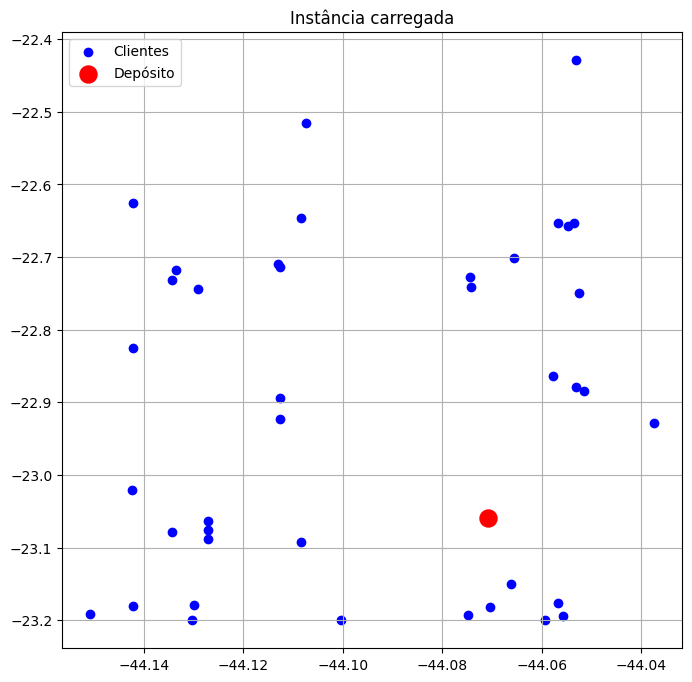

In [ ]:
# ============================================================
# (4) VISUALIZAÇÃO INICIAL DA INSTÂNCIA
# ============================================================
# Antes de construir rotas, vale sempre observar a distribuição espacial
# dos clientes e do depósito.

x_coords = nodes["lon"].values
y_coords = nodes["lat"].values

plt.figure(figsize=(8,8))
plt.scatter(x_coords[1:], y_coords[1:], color="blue", label="Clientes")
plt.scatter(x_coords[0], y_coords[0], color="red", s=150, label="Depósito")
plt.title("Instância carregada")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# ============================================================
# (5) PARÂMETROS LOGÍSTICOS
# ============================================================
# Nesta aula prática, vamos trabalhar com a mesma lógica operacional
# adotada anteriormente no caso da Prolog.

Q = {
    "FIO": 650.0,
    "VUC": 3000.0
}

f = {
    "FIO": 250.0,
    "VUC": 550.0
}

cost_per_km = 1.50
v_kmh = 40.0
H = 8.0

T = D / v_kmh

print("Capacidades:", Q)
print("Custos fixos:", f)
print("Custo variável por km:", cost_per_km)
print("Velocidade média:", v_kmh, "km/h")
print("Jornada de referência:", H, "h")

Capacidades: {'FIO': 650.0, 'VUC': 3000.0}
Custos fixos: {'FIO': 250.0, 'VUC': 550.0}
Custo variável por km: 1.5
Velocidade média: 40.0 km/h
Jornada de referência: 8.0 h


## Pergunta para discussão

Se o método exato da Sprint 1 ficou caro computacionalmente, o que esperamos de uma heurística?

Pense em três dimensões:

1. velocidade de execução;
2. qualidade da solução;
3. simplicidade de implementação.

In [ ]:
# ============================================================
# (6) INSPEÇÃO BÁSICA DE VIABILIDADE
# ============================================================
# Antes de construir rotas, é importante verificar se existe algum cliente
# cuja demanda seja maior do que a capacidade de algum tipo de veículo.
#
# Isso não impede o uso da frota heterogênea, mas ajuda a interpretar a solução:
# por exemplo, um cliente inviável para FIO obrigará a abertura de rota com VUC.

print("Maior demanda da instância:", np.max(q[1:]))

for vehicle in Q:
    infeasible_clients = [i for i in range(1, len(q)) if q[i] > Q[vehicle]]
    print(f"\nClientes inviáveis para {vehicle}: {infeasible_clients}")
    if len(infeasible_clients) > 0:
        print("Demandas correspondentes:", [q[i] for i in infeasible_clients])

Maior demanda da instância: 2452.53

Clientes inviáveis para FIO: [3]
Demandas correspondentes: [np.float64(2452.53)]

Clientes inviáveis para VUC: []


In [ ]:
# ============================================================
# (7) FUNÇÕES AUXILIARES DE ROTA
# ============================================================
# Estas funções calculam medidas importantes de uma rota:
# - distância total;
# - carga total;
# - tempo de serviço;
# - tempo total;
# - custo.
#
# Agora, essas funções terão papel ainda mais importante, porque a
# restrição de jornada será verificada durante a construção da rota.

def route_distance(route, D):
    dist = 0.0
    for a in range(len(route) - 1):
        i = route[a]
        j = route[a + 1]
        dist += D[i, j]
    return dist

def route_load(route, q):
    clients = [node for node in route if node != 0]
    return sum(q[i] for i in clients)

def route_service_time(route, s):
    clients = [node for node in route if node != 0]
    return sum(s[i] for i in clients)

def route_total_time(route, D, s, v_kmh):
    dist = route_distance(route, D)
    t_mov = dist / v_kmh
    t_serv = route_service_time(route, s)
    t_total = t_mov + t_serv
    return t_total, t_mov, t_serv

def route_cost(route, vehicle_type, D, cost_per_km, fixed_costs):
    dist = route_distance(route, D)
    return fixed_costs[vehicle_type] + dist * cost_per_km

def solution_metrics(solution, D, q, s, cost_per_km, fixed_costs, H, v_kmh):
    total_dist = 0.0
    total_cost = 0.0
    total_time = 0.0
    violations = 0

    vehicle_count = {"FIO": 0, "VUC": 0}

    for item in solution:
        route = item["route"]
        vehicle = item["vehicle"]

        dist = route_distance(route, D)
        t_total, _, _ = route_total_time(route, D, s, v_kmh)
        cost = route_cost(route, vehicle, D, cost_per_km, fixed_costs)

        total_dist += dist
        total_time += t_total
        total_cost += cost
        vehicle_count[vehicle] += 1

        if t_total > H + 1e-6:
            violations += 1

    return {
        "n_routes": len(solution),
        "n_fio": vehicle_count["FIO"],
        "n_vuc": vehicle_count["VUC"],
        "total_distance_km": total_dist,
        "total_cost_rs": total_cost,
        "total_time_h": total_time,
        "routes_violating_H": violations
    }

# (7) HEURÍSTICA 1 — NEAREST NEIGHBOR

A heurística do vizinho mais próximo constrói rotas de forma incremental.

A lógica é a seguinte:

1. iniciar no depósito;
2. identificar os clientes ainda não atendidos e viáveis;
3. escolher o cliente viável mais próximo do ponto atual;
4. inserir o cliente na rota;
5. repetir até que não seja mais possível continuar;
6. retornar ao depósito e iniciar uma nova rota.

Nesta aula, vamos aplicar essa lógica ao caso da Prolog considerando, inicialmente, um único tipo de veículo por vez.

In [ ]:
# ============================================================
# (8) ESCOLHA DO PRÓXIMO CLIENTE VIÁVEL
# ============================================================
# Agora, um cliente só será considerado viável se satisfizer
# simultaneamente duas condições:
#
# 1) Capacidade:
#    carga atual + demanda do cliente <= capacidade do veículo
#
# 2) Jornada:
#    ao inserir esse cliente na rota e fechar a rota com retorno ao
#    depósito, o tempo total da rota deve continuar <= H
#
# Ou seja, para testar um cliente j, montamos a rota candidata:
#    rota_atual + [j, 0]
# e verificamos se ela ainda cabe na jornada.

def nearest_feasible_customer_with_time(
    current_node,
    current_route,
    unvisited,
    current_load,
    q,
    D,
    s,
    capacity,
    v_kmh,
    H
):
    feasible = []

    for j in unvisited:
        # Verificação de capacidade
        if current_load + q[j] <= capacity:
            # Monta a rota candidata já retornando ao depósito
            candidate_route = current_route + [j, 0]

            # Calcula o tempo total da rota candidata
            candidate_time, _, _ = route_total_time(candidate_route, D, s, v_kmh)

            # Verificação da jornada
            if candidate_time <= H:
                feasible.append(j)

    if len(feasible) == 0:
        return None

    # Entre os clientes viáveis, escolhemos o mais próximo do nó atual
    next_customer = min(feasible, key=lambda j: D[current_node, j])
    return next_customer

In [ ]:
# ============================================================
# (9) CHECAGEM DE VIABILIDADE INDIVIDUAL DOS CLIENTES
# ============================================================
# Antes de construir a solução completa, vale verificar se cada cliente,
# individualmente, pode ser atendido por cada tipo de veículo.
#
# Para isso, testamos a rota simples:
#    [0, j, 0]
#
# Se essa rota já violar capacidade ou jornada, então aquele cliente é
# inviável para aquele veículo, mesmo sozinho.

def individual_client_feasibility(q, D, s, Q, H, v_kmh):
    results = {}

    for vehicle in Q:
        infeasible_capacity = []
        infeasible_time = []

        for j in range(1, len(q)):
            # Verifica capacidade individual
            if q[j] > Q[vehicle]:
                infeasible_capacity.append(j)
                continue

            # Verifica tempo individual
            single_route = [0, j, 0]
            t_total, _, _ = route_total_time(single_route, D, s, v_kmh)

            if t_total > H:
                infeasible_time.append(j)

        results[vehicle] = {
            "infeasible_capacity": infeasible_capacity,
            "infeasible_time": infeasible_time
        }

    return results

feasibility_report = individual_client_feasibility(q, D, s, Q, H, v_kmh)

for vehicle, rep in feasibility_report.items():
    print(f"\nVeículo: {vehicle}")
    print("Clientes inviáveis por capacidade:", rep["infeasible_capacity"])
    print("Clientes inviáveis por jornada individual:", rep["infeasible_time"])


Veículo: FIO
Clientes inviáveis por capacidade: [3]
Clientes inviáveis por jornada individual: []

Veículo: VUC
Clientes inviáveis por capacidade: []
Clientes inviáveis por jornada individual: []


In [ ]:
# ============================================================
# (10) SIMULAÇÃO DE UMA ROTA COM UM VEÍCULO ESPECÍFICO
# ============================================================
# Esta função constrói UMA rota usando vizinho mais próximo, respeitando:
# - capacidade do veículo;
# - jornada máxima H.
#
# O procedimento é guloso:
# a partir do nó atual, escolhe o cliente viável mais próximo.
#
# A rota é encerrada quando não existe mais nenhum cliente que possa ser
# acrescentado sem violar capacidade ou jornada.

def build_nn_route_for_vehicle(D, q, s, unvisited, capacity, v_kmh, H):
    route = [0]
    current_node = 0
    current_load = 0.0

    # Cópia local para simulação
    remaining = set(unvisited)

    while True:
        next_customer = nearest_feasible_customer_with_time(
            current_node=current_node,
            current_route=route,
            unvisited=remaining,
            current_load=current_load,
            q=q,
            D=D,
            s=s,
            capacity=capacity,
            v_kmh=v_kmh,
            H=H
        )

        if next_customer is None:
            break

        route.append(next_customer)
        remaining.remove(next_customer)
        current_load += q[next_customer]
        current_node = next_customer

    route.append(0)

    clients_served = [node for node in route if node != 0]
    total_time, travel_time, service_time = route_total_time(route, D, s, v_kmh)

    return {
        "route": route,
        "served_clients": clients_served,
        "load": current_load,
        "total_time_h": total_time,
        "travel_time_h": travel_time,
        "service_time_h": service_time
    }

In [ ]:
# ============================================================
# (11) AVALIAÇÃO DE UMA ROTA SIMULADA
# ============================================================
# Agora calculamos os indicadores da rota simulada:
# - número de clientes;
# - carga;
# - distância;
# - custo total;
# - custo por cliente;
# - tempo total.
#
# Esses dados serão usados para decidir qual tipo de veículo deve ser
# escolhido quando uma nova rota for aberta.

def evaluate_route_candidate(route_data, vehicle_type, D, q, s, cost_per_km, fixed_costs, v_kmh):
    route = route_data["route"]
    n_clients = len(route_data["served_clients"])
    dist = route_distance(route, D)
    load = route_load(route, q)
    total_cost = route_cost(route, vehicle_type, D, cost_per_km, fixed_costs)
    total_time, t_mov, t_serv = route_total_time(route, D, s, v_kmh)

    if n_clients > 0:
        cost_per_client = total_cost / n_clients
    else:
        cost_per_client = math.inf

    return {
        "vehicle": vehicle_type,
        "route": route,
        "served_clients": route_data["served_clients"],
        "n_clients": n_clients,
        "load": load,
        "distance_km": dist,
        "total_cost_rs": total_cost,
        "cost_per_client_rs": cost_per_client,
        "total_time_h": total_time,
        "travel_time_h": t_mov,
        "service_time_h": t_serv
    }

In [ ]:
# ============================================================
# (12) ESCOLHA DO TIPO DE VEÍCULO PARA UMA NOVA ROTA
# ============================================================
# Ao abrir uma nova rota, simulamos a construção dessa rota com cada
# tipo de veículo disponível.
#
# Como agora a rota precisa respeitar também a jornada H, cada simulação
# pode resultar em uma rota diferente não apenas pela capacidade, mas
# também pelo tempo disponível.
#
# Critérios possíveis:
# - "total_cost"
# - "cost_per_client"

def choose_best_vehicle_for_new_route(
    D, q, s, unvisited, Q, f, cost_per_km, v_kmh, H, criterion="total_cost"
):
    candidates = []

    for vehicle in Q:
        route_data = build_nn_route_for_vehicle(
            D=D,
            q=q,
            s=s,
            unvisited=unvisited,
            capacity=Q[vehicle],
            v_kmh=v_kmh,
            H=H
        )

        eval_data = evaluate_route_candidate(
            route_data=route_data,
            vehicle_type=vehicle,
            D=D,
            q=q,
            s=s,
            cost_per_km=cost_per_km,
            fixed_costs=f,
            v_kmh=v_kmh
        )

        if eval_data["n_clients"] > 0:
            candidates.append(eval_data)

    if len(candidates) == 0:
        raise ValueError(
            "Nenhum veículo conseguiu atender os clientes restantes "
            "respeitando capacidade e jornada. "
            f"Clientes restantes: {sorted(unvisited)}"
        )

    if criterion == "total_cost":
        best = min(
            candidates,
            key=lambda x: (x["total_cost_rs"], -x["n_clients"], x["distance_km"])
        )

    elif criterion == "cost_per_client":
        best = min(
            candidates,
            key=lambda x: (x["cost_per_client_rs"], -x["n_clients"], x["total_cost_rs"])
        )

    else:
        raise ValueError("Critério inválido. Use 'total_cost' ou 'cost_per_client'.")

    return best, candidates

In [ ]:
# ============================================================
# (13) CONSTRUÇÃO DA SOLUÇÃO COMPLETA
# ============================================================
# Enquanto houver clientes não atendidos:
# - simulamos a próxima rota com FIO;
# - simulamos a próxima rota com VUC;
# - ambas respeitando capacidade e jornada;
# - escolhemos a melhor alternativa segundo o critério adotado;
# - removemos os clientes atendidos;
# - repetimos.
#
# Assim, a escolha do veículo é feita de forma dinâmica, rota a rota.

def nearest_neighbor_heterogeneous(
    D, q, s, Q, f, cost_per_km, v_kmh, H, criterion="total_cost", verbose=True
):
    unvisited = set(range(1, len(q)))
    solution = []
    route_id = 1

    while len(unvisited) > 0:
        best_route, all_candidates = choose_best_vehicle_for_new_route(
            D=D,
            q=q,
            s=s,
            unvisited=unvisited,
            Q=Q,
            f=f,
            cost_per_km=cost_per_km,
            v_kmh=v_kmh,
            H=H,
            criterion=criterion
        )

        for client in best_route["served_clients"]:
            unvisited.remove(client)

        solution.append({
            "route_id": route_id,
            "vehicle": best_route["vehicle"],
            "route": best_route["route"],
            "served_clients": best_route["served_clients"],
            "n_clients": best_route["n_clients"],
            "load": best_route["load"],
            "distance_km": best_route["distance_km"],
            "total_cost_rs": best_route["total_cost_rs"],
            "cost_per_client_rs": best_route["cost_per_client_rs"],
            "total_time_h": best_route["total_time_h"]
        })

        if verbose:
            print(f"Rota {route_id}: veículo {best_route['vehicle']}")
            print("  sequência:", best_route["route"])
            print("  clientes atendidos:", best_route["served_clients"])
            print("  carga total (kg):", round(best_route["load"], 2))
            print("  distância (km):", round(best_route["distance_km"], 2))
            print("  tempo total (h):", round(best_route["total_time_h"], 2))
            print("  custo total (R$):", round(best_route["total_cost_rs"], 2))
            print("  custo por cliente (R$):", round(best_route["cost_per_client_rs"], 2))
            print()

        route_id += 1

    return solution

In [ ]:
# ============================================================
# (14) DEFINIÇÃO DO CRITÉRIO DE DECISÃO
# ============================================================
# Nesta célula escolhemos o critério usado para decidir, a cada nova rota,
# qual veículo deve ser mobilizado.
#
# Opções:
# - "total_cost"
# - "cost_per_client"

criterion = "total_cost"

print("Critério de seleção adotado:", criterion)

Critério de seleção adotado: total_cost


In [ ]:
# ============================================================
# (15) EXECUÇÃO DA HEURÍSTICA
# ============================================================
# Agora rodamos a heurística completa, com:
# - frota heterogênea;
# - restrição de capacidade;
# - restrição de jornada embutida na construção.

start = time.time()

solution_nn_het = nearest_neighbor_heterogeneous(
    D=D,
    q=q,
    s=s,
    Q=Q,
    f=f,
    cost_per_km=cost_per_km,
    v_kmh=v_kmh,
    H=H,
    criterion=criterion,
    verbose=True
)

elapsed = time.time() - start

print("Tempo computacional (s):", elapsed)

Rota 1: veículo FIO
  sequência: [0, 17, 35, 30, 8, 16, 9, 1, 10, 5, 23, 12, 36, 15, 11, 7, 20, 2, 4, 0]
  clientes atendidos: [17, 35, 30, 8, 16, 9, 1, 10, 5, 23, 12, 36, 15, 11, 7, 20, 2, 4]
  carga total (kg): 641.42
  distância (km): 129.3
  tempo total (h): 7.73
  custo total (R$): 443.95
  custo por cliente (R$): 24.66

Rota 2: veículo FIO
  sequência: [0, 25, 38, 21, 13, 14, 40, 28, 26, 27, 39, 19, 32, 31, 6, 29, 33, 34, 0]
  clientes atendidos: [25, 38, 21, 13, 14, 40, 28, 26, 27, 39, 19, 32, 31, 6, 29, 33, 34]
  carga total (kg): 553.89
  distância (km): 140.4
  tempo total (h): 7.76
  custo total (R$): 460.6
  custo por cliente (R$): 27.09

Rota 3: veículo FIO
  sequência: [0, 24, 18, 37, 22, 0]
  clientes atendidos: [24, 18, 37, 22]
  carga total (kg): 69.62
  distância (km): 144.25
  tempo total (h): 4.61
  custo total (R$): 466.37
  custo por cliente (R$): 116.59

Rota 4: veículo VUC
  sequência: [0, 3, 0]
  clientes atendidos: [3]
  carga total (kg): 2452.53
  distância (

In [ ]:
# ============================================================
# (16) MÉTRICAS GERAIS DA SOLUÇÃO
# ============================================================
# Como a jornada já foi considerada durante a construção da solução,
# esperamos que o número de rotas violando H seja zero, salvo pequenas
# diferenças numéricas de arredondamento.

metrics = solution_metrics(
    solution=solution_nn_het,
    D=D,
    q=q,
    s=s,
    cost_per_km=cost_per_km,
    fixed_costs=f,
    H=H,
    v_kmh=v_kmh
)

print("Métricas gerais da solução:")
print(metrics)

Métricas gerais da solução:
{'n_routes': 4, 'n_fio': 3, 'n_vuc': 1, 'total_distance_km': np.float64(440.9717507524413), 'total_cost_rs': np.float64(1961.457626128662), 'total_time_h': np.float64(21.02429376881103), 'routes_violating_H': 0}


In [ ]:
# ============================================================
# (17) TABELA RESUMO DAS ROTAS
# ============================================================
# Esta tabela resume cada rota construída, indicando:
# - veículo escolhido;
# - sequência de atendimento;
# - carga;
# - distância;
# - custo;
# - tempo total;
# - atendimento ou não da jornada.

summary_rows = []

for item in solution_nn_het:
    summary_rows.append({
        "route_id": item["route_id"],
        "vehicle": item["vehicle"],
        "route": str(item["route"]),
        "n_clients": item["n_clients"],
        "load_kg": round(item["load"], 2),
        "distance_km": round(item["distance_km"], 2),
        "total_cost_rs": round(item["total_cost_rs"], 2),
        "cost_per_client_rs": round(item["cost_per_client_rs"], 2),
        "total_time_h": round(item["total_time_h"], 2),
        "violates_H": item["total_time_h"] > H + 1e-6
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,route_id,vehicle,route,n_clients,load_kg,distance_km,total_cost_rs,cost_per_client_rs,total_time_h,violates_H
0,1,FIO,"[0, 17, 35, 30, 8, 16, 9, 1, 10, 5, 23, 12, 36...",18,641.42,129.30,443.95,24.66,7.73,False
1,2,FIO,"[0, 25, 38, 21, 13, 14, 40, 28, 26, 27, 39, 19...",17,553.89,140.40,460.60,27.09,7.76,False
2,3,FIO,"[0, 24, 18, 37, 22, 0]",4,69.62,144.25,466.37,116.59,4.61,False
3,4,VUC,"[0, 3, 0]",1,2452.53,27.02,590.53,590.53,0.93,False


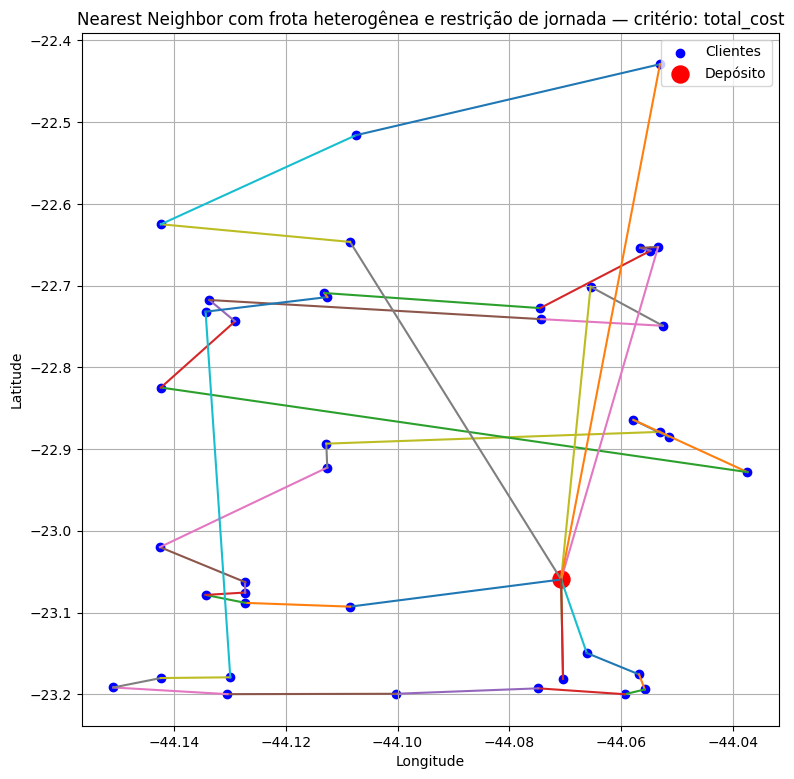

In [ ]:
# ============================================================
# (18) VISUALIZAÇÃO DAS ROTAS
# ============================================================
# Vamos visualizar a solução construída.
# O depósito aparece em vermelho e os clientes em azul.

def plot_solution(solution, nodes, title):
    x_coords = nodes["lon"].values
    y_coords = nodes["lat"].values

    plt.figure(figsize=(9, 9))
    plt.scatter(x_coords[1:], y_coords[1:], color="blue", label="Clientes")
    plt.scatter(x_coords[0], y_coords[0], color="red", s=150, label="Depósito")

    for item in solution:
        route = item["route"]
        for i in range(len(route) - 1):
            a = route[i]
            b = route[i + 1]
            plt.plot([x_coords[a], x_coords[b]], [y_coords[a], y_coords[b]])

    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_solution(
    solution_nn_het,
    nodes,
    f"Nearest Neighbor com frota heterogênea e restrição de jornada — critério: {criterion}"
)

In [ ]:
# ============================================================
# (19) COMPARAÇÃO ENTRE CRITÉRIOS DE DECISÃO
# ============================================================
# Agora comparamos os dois critérios de seleção do veículo:
# - menor custo total da rota
# - menor custo por cliente atendido
#
# Como a jornada já está embutida, as soluções comparadas já respeitam
# a restrição de tempo durante a construção.

results_compare = []

for crit in ["total_cost", "cost_per_client"]:
    start = time.time()

    sol = nearest_neighbor_heterogeneous(
        D=D,
        q=q,
        s=s,
        Q=Q,
        f=f,
        cost_per_km=cost_per_km,
        v_kmh=v_kmh,
        H=H,
        criterion=crit,
        verbose=False
    )

    elapsed = time.time() - start

    met = solution_metrics(
        solution=sol,
        D=D,
        q=q,
        s=s,
        cost_per_km=cost_per_km,
        fixed_costs=f,
        H=H,
        v_kmh=v_kmh
    )

    met["criterion"] = crit
    met["elapsed_s"] = elapsed
    results_compare.append(met)

df_compare = pd.DataFrame(results_compare)
df_compare

,n_routes,n_fio,n_vuc,total_distance_km,total_cost_rs,total_time_h,routes_violating_H,criterion,elapsed_s
0,4,3,1,440.971751,1961.457626,21.024294,0,total_cost,0.013309
1,4,3,1,440.971751,1961.457626,21.024294,0,cost_per_client,0.010390


In [ ]:
# ============================================================
# (20) DISCUSSÃO FINAL
# ============================================================
# Pontos importantes para análise:
#
# 1) A inclusão da jornada reduziu o tamanho médio das rotas?
# 2) O algoritmo passou a usar mais VUC ou mais FIO?
# 3) O critério adotado alterou a composição da solução?
# 4) O número de rotas aumentou após impor H = 8h?
# 5) A solução continuou sem violações de jornada?

print("Encerramento da prática:")
print("- Compare a solução antes e depois de incorporar a jornada.")
print("- Observe como a restrição de 8h afeta o número de clientes por rota.")
print("- Verifique se a composição da frota mudou.")
print("- Analise a diferença entre os critérios de decisão.")
print("- Discuta as limitações do método guloso utilizado.")

Encerramento da prática:
- Compare a solução antes e depois de incorporar a jornada.
- Observe como a restrição de 8h afeta o número de clientes por rota.
- Verifique se a composição da frota mudou.
- Analise a diferença entre os critérios de decisão.
- Discuta as limitações do método guloso utilizado.


In [ ]:
# ============================================================
# (21) SALVAR SOLUÇÃO NN PARA A AULA DE BUSCA LOCAL
# ============================================================
# A solução gerada nesta aula será usada como ponto de partida
# para a próxima aula, em que aplicaremos heurísticas de melhoria
# como 2-opt e relocate.
#
# Por isso, vamos salvar a solução em um arquivo JSON.

import json
from google.colab import files

def save_solution_json(solution, filename):
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(solution, f, indent=4, ensure_ascii=False)

save_solution_json(solution_nn_het, "solution_nn_het.json")

files.download("solution_nn_het.json")

print("Arquivo solution_nn_het.json salvo e disponível para download.")